# Student Score Prediction

This notebook builds a model to **predict exam scores** from study hours
using **Python, Pandas, Matplotlib, and Scikit-learn**.

**Covers:** data loading, cleaning, visualization, train/test split, linear regression, evaluation metrics (MSE, R²), polynomial regression (bonus), and feature experiments.

> **Dataset:** *Student Performance Factors*.**Available:**https://www.kaggle.com/datasets/lainguyn123/student-performance-factors




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
print('Setup complete.')

Setup complete.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load & Inspect Data
If your CSV uses different column names, adjust them in later cells accordingly.


In [ ]:
csv_path = '/content/drive/MyDrive/Colab Notebooks/data/StudentPerformanceFactors.csv'
df = pd.read_csv(csv_path)
print('Shape:', df.shape)
display(df.head(20))
display(df.info())

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

None

## Data Cleaning
- Quick missing-value handling (drop or simple impute)
- Optional: convert types or encode categories if present


In [ ]:
# Check missing values
print(df.isna().sum())

# Simple approach: drop rows with any missing values
df = df.dropna().copy()
print('After dropna, shape:', df.shape)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
After dropna, shape: (6378, 20)


## Basic Visualization (Matplotlib)
We'll plot StudyHours vs ExamScore. Adjust column names if yours differ.

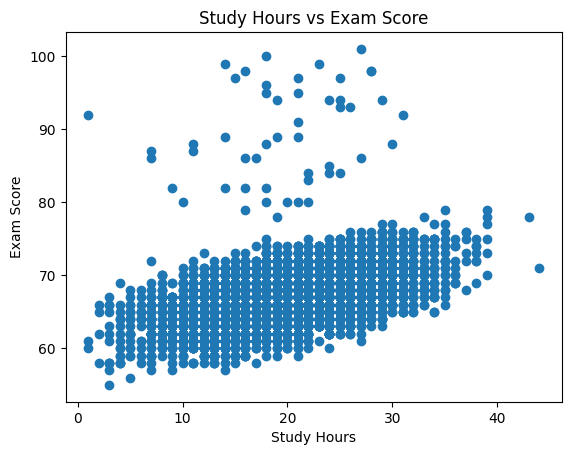

In [ ]:
# Rename columns here if needed
study_col = 'Hours_Studied'
target_col = 'Exam_Score'

assert study_col in df.columns, f"Column '{study_col}' not found. Update study_col."
assert target_col in df.columns, f"Column '{target_col}' not found. Update target_col."

plt.figure()
plt.scatter(df[study_col], df[target_col])
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')
plt.show()

## Train/Test Split

In [ ]:
X = df[[study_col]]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((5102, 1), (1276, 1))

## Linear Regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Intercept: {lin_reg.intercept_:.3f}")
print(f"Coefficient (per study hour): {lin_reg.coef_[0]:.3f}")
print(f"Test MSE: {mse:.3f}")
print(f"Test R^2: {r2:.3f}")

Intercept: 61.490
Coefficient (per study hour): 0.288
Test MSE: 12.352
Test R^2: 0.205


### Visualize Predictions

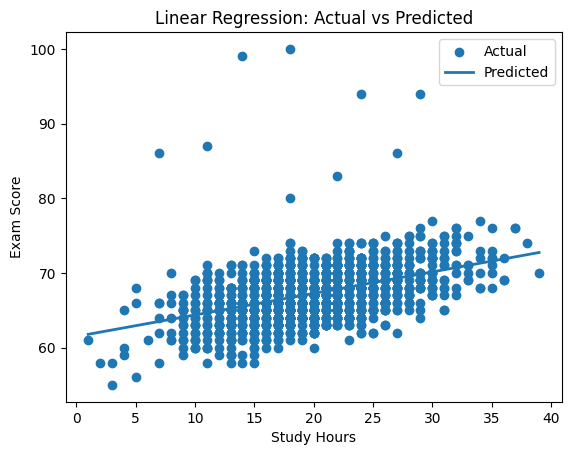

In [ ]:
order = np.argsort(X_test[study_col].values)
X_sorted = X_test.iloc[order]
y_sorted = y_test.iloc[order]
y_pred_sorted = y_pred[order]

plt.figure()
plt.scatter(X_sorted[study_col], y_sorted, label='Actual')
plt.plot(X_sorted[study_col], y_pred_sorted, linewidth=2, label='Predicted')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()

## Bonus: Polynomial Regression (degree=2)
This can model curvature if the relationship isn't perfectly linear.

Polynomial (deg=2) Test MSE: 12.353
Polynomial (deg=2) Test R^2: 0.205


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


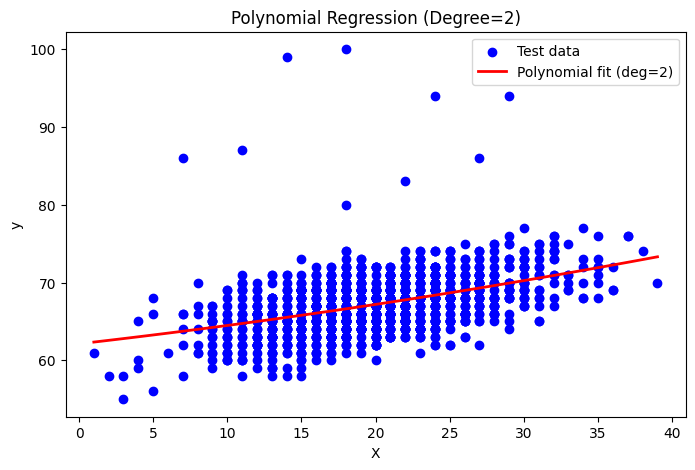

In [ ]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin', LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial (deg=2) Test MSE: {mse_poly:.3f}")
print(f"Polynomial (deg=2) Test R^2: {r2_poly:.3f}")

X_plot = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_plot = poly_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="blue", label="Test data")
plt.plot(X_plot, y_plot, color="red", linewidth=2, label="Polynomial fit (deg=2)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree=2)")
plt.legend()
plt.show()

### Feature Experiments
If your dataset contains other columns like `SleepHours`, `Attendance`, `Participation`, try adding them below.
If a column isn't present, remove it from the list.

In [ ]:
# Example: add optional features if they exist
candidate_cols = ['StudyHours', 'Sleep_Hours', 'Attendance', 'Tutoring session']
feat_cols = [c for c in candidate_cols if c in df.columns]
print('Using features:', feat_cols)

X2 = df[feat_cols]
y2 = df[target_col]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lin_reg2 = LinearRegression().fit(X2_train, y2_train)
y2_pred = lin_reg2.predict(X2_test)
print('Multi-Feature Test MSE:', mean_squared_error(y2_test, y2_pred))
print('Multi-Feature Test R^2:', r2_score(y2_test, y2_pred))
print('Coefficients:')
for name, coef in zip(feat_cols, lin_reg2.coef_):
    print(f"  {name}: {coef:.4f}")

Using features: ['Sleep_Hours', 'Attendance']
Multi-Feature Test MSE: 9.985193744971989
Multi-Feature Test R^2: 0.3574242283150151
Coefficients:
  Sleep_Hours: -0.0154
  Attendance: 0.1946


## Save Trained Model
Saves the linear model trained on the single-feature setup.

In [ ]:
import joblib
joblib.dump(lin_reg, 'student_score_linear_model.joblib')
print('Saved to student_score_linear_model.joblib')

Saved to student_score_linear_model.joblib
